<a href="https://colab.research.google.com/github/laurakeita/MMM/blob/main/MMM_meridian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/google/meridian.git

  Cloning https://github.com/google/meridian.git to /tmp/pip-req-build-fq7j4jrc
  Running command git clone --filter=blob:none --quiet https://github.com/google/meridian.git /tmp/pip-req-build-fq7j4jrc
  Resolved https://github.com/google/meridian.git to commit 036431ed36d37786c4b92bde6881f7281cc49755
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install altair

In [3]:
!pip install jsonschema==3.2.0
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import arviz as az

import IPython
import jsonschema
import importlib

# Reload jsonschema to ensure the newly installed version is active
importlib.reload(jsonschema)

from meridian import constants
from meridian.data import load
from meridian.data import test_utils
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution
from meridian.analysis import optimizer
from meridian.analysis import analyzer
from meridian.analysis import visualizer
from meridian.analysis import summarizer
from meridian.analysis import formatter

# check if GPU is available
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.experimental.list_physical_devices('CPU')))

Your runtime has 13.6 gigabytes of available RAM

Num GPUs Available:  0
Num CPUs Available:  1


In [9]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

gcs_file_path = '/content/MMM1.csv'

# Keep on_bad_lines='skip' in case there are still parsing issues from previous attempts
data = pd.read_csv(gcs_file_path, on_bad_lines='skip')
print(data.columns)

# Identify columns that contain spend-related keywords (e.g., 'spend', 'cost', 'budget')
media = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in ['spend', 'cost', 'budget'])
]

# Exclude media channels with zero total spend
media = [col for col in media if data[col].sum() > 0]


print("Selected Media Channels:", media)

impressions =  [
    col for col in data.columns
    if "impression" in col.lower() or "impresseion" in col.lower()
]

print("Impressions List:", impressions)


# Convert 'date' column to datetime objects using the specified format yyyy/mm/dd
try:
    data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d', errors='coerce')
except Exception as e:
    print(f"Could not convert 'date' to datetime: {e}")

# Drop rows where date conversion failed (i.e., 'date' is NaT)
data = data.dropna(subset=['date'])

# Identify the output (revenue) column(s)
output = [
    col for col in data.columns
    if 'revenue' in col.lower()
]

# Create a time index t
data['t'] = range(len(data))

# Separate features (X) and target (y)
X = data.drop(output, axis=1)
y = data[output[0]]  # if there is only one revenue column


display(data.head())

Index(['date', 'Revenue', 'Meta spend', 'Meta impression', 'Meta click',
       'Meta convert', 'Google spend', 'Google impression', 'Google click',
       'Google convert', 'Offline Discount'],
      dtype='object')
Selected Media Channels: ['Meta spend', 'Google spend']
Impressions List: ['Meta impression', 'Google impression']


,date,Revenue,Meta spend,Meta impression,Meta click,Meta convert,Google spend,Google impression,Google click,Google convert,Offline Discount,t
0,2024-01-01,11100,1395,15514,1091,0,398,1145,115,0,0,0
1,2024-01-02,7720,1394,12432,806,7720,390,1352,109,0,0,1
2,2024-01-03,1770,1282,10824,686,1770,348,1134,94,0,0,2
3,2024-01-04,4300,1279,11359,610,0,381,985,84,0,0,3
4,2024-01-05,8635,1276,10482,666,0,378,1116,100,0,0,4


******** Spend Share Analysis ********
  Media_Channel  Spend_Share
0    Meta spend     0.651362
1  Google spend     0.348638


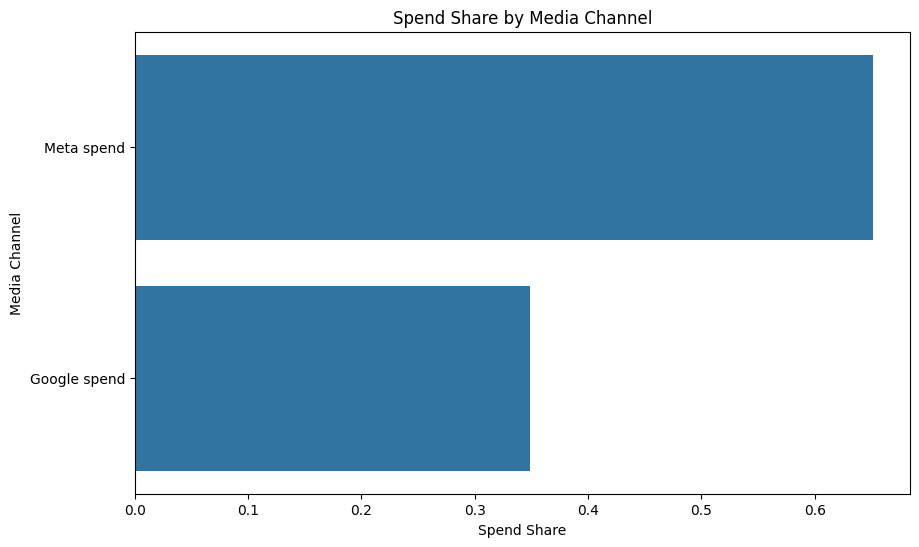


******** Correlation Analysis ********
Using revenue column: Revenue
Correlation of inputs with Revenue:
Meta convert         0.501729
Google click         0.140909
Offline Discount     0.110608
Meta click           0.093669
Google impression    0.067904
Google spend         0.064487
t                    0.047195
Google convert       0.046062
Meta spend           0.007079
Meta impression      0.001944
Name: Revenue, dtype: float64


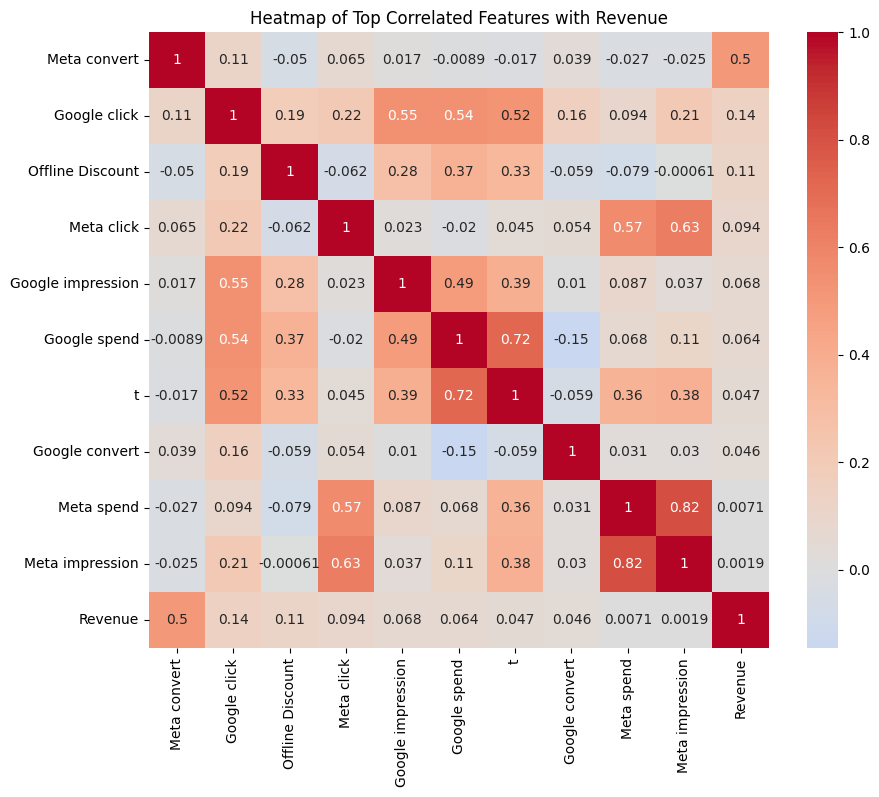


******** Multicollinearity Analysis ********
             Feature        VIF
0         Meta spend  43.906361
1    Meta impression  42.243484
2         Meta click  19.914805
6       Google click  15.578100
9                  t  11.926816
4       Google spend  10.746496
5  Google impression   6.858058
8   Offline Discount   1.764435
3       Meta convert   1.242040
7     Google convert   1.134990

******** Variables with Less Than 15 Records ********
All variables have at least 15 records.


In [10]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ----------------------------
# 1. Spend Share Analysis
# ----------------------------
print("******** Spend Share Analysis ********")
if media:
    # Calculate total spend across all identified media channels.
    total_media_spend = data[media].sum().sum()
    # Compute spend share for each media channel.
    spend_share = data[media].sum() / total_media_spend
    spend_share_df = spend_share.reset_index()
    spend_share_df.columns = ['Media_Channel', 'Spend_Share']
    print(spend_share_df)

    # Plot a bar chart of spend share.
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Spend_Share', y='Media_Channel',
                data=spend_share_df.sort_values(by='Spend_Share', ascending=False))
    plt.title("Spend Share by Media Channel")
    plt.xlabel("Spend Share")
    plt.ylabel("Media Channel")
    plt.show()
else:
    print("No media channels available for spend share analysis.")


# ----------------------------
# 2. Correlation Analysis between Inputs and Output (ecommerce_revenue)
# ----------------------------
print("\n******** Correlation Analysis ********")
revenue_col = output[0] if output and output[0] in data.columns else 'ecommerce_revenue'
print("Using revenue column:", revenue_col)

numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

if revenue_col in corr_matrix.columns:
    corr_with_rev = corr_matrix[revenue_col].drop(labels=[revenue_col]).sort_values(ascending=False)
    print("Correlation of inputs with {}:".format(revenue_col))
    print(corr_with_rev)

    # Identify top 10 features most correlated (by absolute value) with the revenue.
    top_features = corr_with_rev.abs().sort_values(ascending=False).head(10).index.tolist() + [revenue_col]

    # Plot a heatmap displaying correlations among these top features.
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_data[top_features].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title("Heatmap of Top Correlated Features with {}".format(revenue_col))
    plt.show()
else:
    print("Revenue column not found in the correlation matrix.")


# ----------------------------
# 3. Multicollinearity Analysis (Variance Inflation Factor)
# ----------------------------
print("\n******** Multicollinearity Analysis ********")
# Use the feature set X defined earlier; select only numeric columns.
X_numeric = X.select_dtypes(include=[np.number])
if not X_numeric.empty:
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X_numeric.columns
    # Calculate VIF for each feature.
    vif_df["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                     for i in range(X_numeric.shape[1])]
    print(vif_df.sort_values(by="VIF", ascending=False))
else:
    print("No numeric features available in X for multicollinearity analysis.")


# ----------------------------
# 4. Check for Variables with Less Than 15 Records
# ----------------------------
print("\n******** Variables with Less Than 15 Records ********")
low_record_columns = {col: data[col].count() for col in data.columns if data[col].count() < 15}
if low_record_columns:
    for col, cnt in low_record_columns.items():
        print(f"Column '{col}' has only {cnt} recorded non-null entries.")
else:
    print("All variables have at least 15 records.")


In [11]:
def create_channel_mappings(media, impressions):
    """
    Generate mapping dictionaries for media spend and impressions columns.

    Parameters:
        media (list of str): List of column names with spend/cost data.
                             Expected to have columns ending with '_spend'. # Reverted docstring to original expectation
        impressions (list of str): List of column names with impressions data.
                                   Expected to have columns ending with 'impression' or 'impresseion'. # Updated docstring
                                   Note: If this list contains spend columns (as in the original call),
                                   the resulting 'impressions_mapping' might not be meaningful for impression data.

    Returns:
        tuple: Two dictionaries:
            - correct_media_spend_to_channel: Mapping of spend/cost column names to simplified channel names.
            - correct_media_to_channel: Mapping of impressions column names to simplified channel names.
    """
    correct_media_spend_to_channel = {}
    for col in media:
        if col.endswith("spend"):
            channel_name = col[:-len("spend")]
        else:
            channel_name = col
        correct_media_spend_to_channel[col] = channel_name

    correct_media_to_channel = {}
    for col in impressions:
        col_lower = col.lower()
        if col_lower.endswith("impression"):
            channel_name = col[:-len("impression")]
        elif col_lower.endswith("impresseion"):
            channel_name = col[:-len("impresseion")]
        else:
            channel_name = col
        correct_media_to_channel[col] = channel_name

    return correct_media_spend_to_channel, correct_media_to_channel

# Correctly call create_channel_mappings passing media and impressions lists
cost_mapping, impressions_mapping = create_channel_mappings(media, impressions)

print("Cost Mapping:", cost_mapping)
print("Impressions Mapping:", impressions_mapping)

Cost Mapping: {'Meta spend': 'Meta ', 'Google spend': 'Google '}
Impressions Mapping: {'Meta impression': 'Meta ', 'Google impression': 'Google '}


In [ ]:
skip_seasonality = True

if not skip_seasonality:
  def create_seasonality_features(data: pd.DataFrame, date_column: str, output_variable: str, yearly_seasonality: int) -> pd.DataFrame:
    """
    Creates seasonality effect features for modeling based on the yearly seasonality using the statsmodels library.
    Handles ValueError by using additive seasonality.

    Parameters:
    - data (pd.DataFrame): The input dataframe.
    - date_column (str): The name of the date column.
    - output_variable (str): The name of the output variable.
    - yearly_seasonality (int): The yearly seasonality period (e.g., 52 for weekly, 365 for daily).

    Returns:
    - pd.DataFrame: The dataframe with added seasonality features.
    """

    # Ensure the date column is in datetime format
    data[date_column] = pd.to_datetime(data[date_column])

    # Sort the data by date
    data = data.sort_values(by=date_column)

    # Set the date column as index for seasonal decomposition
    data.set_index(date_column, inplace=True)

    # try multiplicative if not then additive
    try:
        decomposition = seasonal_decompose(data[output_variable], model='multiplicative', period=yearly_seasonality)
    except ValueError as e:
        print(f"Multiplicative decomposition failed: {e}. Switching to additive model.")
        decomposition = seasonal_decompose(data[output_variable], model='additive', period=yearly_seasonality)


    # Add seasonal component as a feature
    data[f'seasonal_{output_variable}'] = decomposition.seasonal

    # Reset index to retain the date column
    data.reset_index(inplace=True)

    return data

# Example usage
# Use the actual output column name identified from the data (stored in output[0])
  data = create_seasonality_features(
    data,
    date_column='date',
    output_variable=output[0],  # Modified to use the actual revenue column name
    yearly_seasonality=52
  )

  data.head()

else:
    print("Skipping seasonality feature creation due to insufficient data.")



In [12]:
from meridian.data import load
import numpy as np # Import numpy for array comparison

print(data.columns)

coord_to_columns = load.CoordToColumns(
    time='date', # Assuming the date/week column is named 'date'
    kpi='Revenue',
    controls=['Offline Discount'],
    media=impressions, # Pass the list of impression columns
    media_spend=media, # Pass the list of spend columns
)

# Add a check to compare impressions list and impressions_mapping keys
print("\nComparing impressions list and impressions_mapping keys:")
print("Impressions list:", impressions)
print("Impressions mapping keys:", list(impressions_mapping.keys()))

# Check if keys match the impressions list
if np.array_equal(sorted(impressions), sorted(list(impressions_mapping.keys()))):
    print("Impressions list and impressions_mapping keys match.")
else:
    print("Impressions list and impressions_mapping keys DO NOT match.")


loader = load.DataFrameDataLoader(
    df=data, # Use the data variable
    kpi_type='revenue',
    coord_to_columns=coord_to_columns,
    media_spend_to_channel=cost_mapping,
    media_to_channel=impressions_mapping, # Add the impressions mapping
)
data_meridian = loader.load()

Index(['date', 'Revenue', 'Meta spend', 'Meta impression', 'Meta click',
       'Meta convert', 'Google spend', 'Google impression', 'Google click',
       'Google convert', 'Offline Discount', 't'],
      dtype='object')

Comparing impressions list and impressions_mapping keys:
Impressions list: ['Meta impression', 'Google impression']
Impressions mapping keys: ['Meta impression', 'Google impression']
Impressions list and impressions_mapping keys match.


/usr/local/lib/python3.12/dist-packages/meridian/data/input_data.py:517: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(


In [13]:
data_meridian.as_dataset()

<xarray.Dataset> Size: 103kB
Dimensions:           (time: 366, geo: 1, control_variable: 1,
                       media_channel: 2, media_time: 366)
Coordinates:
  * time              (time) <U28 41kB '2024-01-01' ... '2024-12-31'
  * geo               (geo) <U12 48B 'national_geo'
  * control_variable  (control_variable) object 8B 'Offline Discount'
  * media_channel     (media_channel) object 16B 'Meta ' 'Google '
  * media_time        (media_time) <U28 41kB '2024-01-01' ... '2024-12-31'
Data variables:
    kpi               (geo, time) int64 3kB 11100 7720 1770 ... 4531 6300 10
    population        (geo) float64 8B 1.0
    controls          (geo, time, control_variable) int64 3kB 0 0 0 0 ... 1 1 1
    revenue_per_kpi   (geo, time) float64 3kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    media             (geo, media_time, media_channel) int64 6kB 15514 ... 2885
    media_spend       (geo, time, media_channel) int64 6kB 1395 398 ... 1602 593

In [14]:
#functiom to translate the media ROI into a log normal distribution usable by the model prios

def estimate_lognormal_dist(mean, std):
    """
    Reparameterizes the LogNormal distribution in terms of its mean and std.
    Returns mu_log and std_log which can be used to define a LogNormal.
    """
    mu_log = np.log(mean) - 0.5 * np.log((std/mean)**2 + 1)
    std_log = np.sqrt(np.log((std/mean)**2 + 1))
    return mu_log, std_log

roi_mu= 2
roi_sigma= 1.5

roi_mu_log, roi_sigma_log=estimate_lognormal_dist(roi_mu, roi_sigma)
print(roi_mu_log, roi_sigma_log)
"""
# setting priors based on spend share
total_spend= data[media].sum().sum()
priors={'mu':[], 'sigma':[]}
for i in media:
  spend_share=(data[i].sum()/total_spend)*2
  roi_sigma=roi_mu*spend_share
  mu , sigma= estimate_lognormal_dist(roi_mu, roi_sigma)
  priors['mu'].append(mu)
  priors['sigma'].append(sigma)

print(priors)

roi_mu=priors['mu']
roi_sigma=priors['sigma']
print(roi_mu)"""


0.4700036292457355 0.6680472308365776


"\n# setting priors based on spend share\ntotal_spend= data[media].sum().sum()\npriors={'mu':[], 'sigma':[]}\nfor i in media:\n  spend_share=(data[i].sum()/total_spend)*2\n  roi_sigma=roi_mu*spend_share\n  mu , sigma= estimate_lognormal_dist(roi_mu, roi_sigma)\n  priors['mu'].append(mu)\n  priors['sigma'].append(sigma)\n\nprint(priors)\n\nroi_mu=priors['mu']\nroi_sigma=priors['sigma']\nprint(roi_mu)"

In [15]:
# Prior Distribution
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(
       loc=np.float32(roi_mu_log),
       scale=np.float32(roi_sigma_log),
       name=constants.ROI_M)
)

# Build Meridian Model
# Initializing ModelSpec directly with parameters from the old create_model_spec call and the prior
# Mapping n_lags and adstock_max_lag_weight to max_lag (assuming this is the correct parameter name)
model_spec = spec.ModelSpec(
    prior=prior,
    max_lag=7, # Assuming adstock_max_lag_weight maps to max_lag
)

# Initialize the model for posterior sampling
mmm = model.Meridian(input_data=data_meridian, model_spec=model_spec)

/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


In [16]:
from tqdm import tqdm
mmm = model.Meridian(input_data=data_meridian, model_spec=model_spec)
mmm.sample_prior(100)  # Should now work without dtype mismatch

mmm.sample_posterior(
    n_chains=5,
    n_adapt=1000,
    n_burnin=1000,
    n_keep=2000,
)

model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.predictive_accuracy_table()



/usr/local/lib/python3.12/dist-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/model/prior_distribution.py:1325: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.12/dist-p

,metric,geo_granularity,value
0,R_Squared,national,0.013827
1,MAPE,national,246.130936
2,wMAPE,national,0.893788


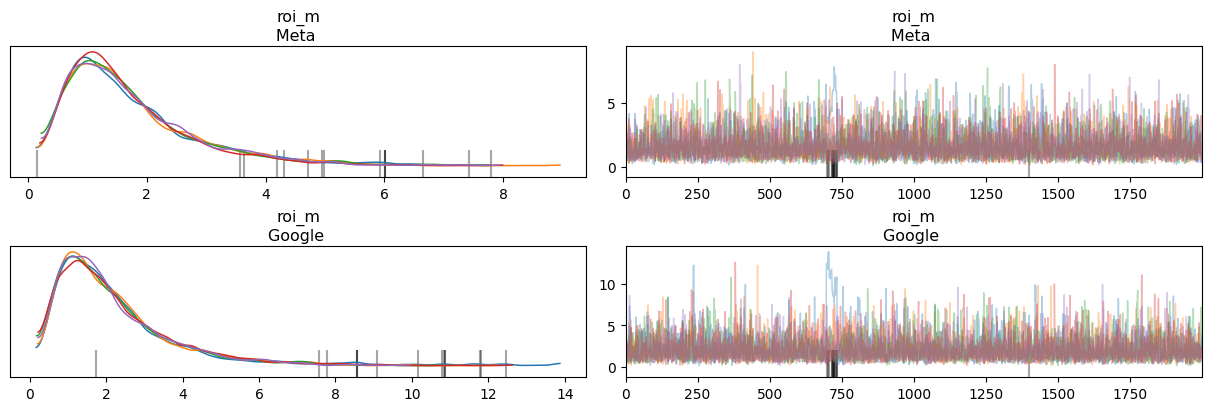

In [17]:
parameters_to_plot=["roi_m"]
for params in parameters_to_plot:
  az.plot_trace(
      mmm.inference_data,
      var_names=params,
      compact=False,
      backend_kwargs={"constrained_layout": True},
  )


In [18]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

alt.LayerChart(...)

In [19]:
from meridian.analysis import summarizer
mmm_summarizer = summarizer.Summarizer(mmm)
#save output
from google.colab import drive
drive.mount('/content/drive')


filepath = '/content/drive/MyDrive'
start_date = '2024-01-25'
end_date = '2024-03-15'
mmm_summarizer.output_model_results_summary('summary_output.html', filepath, start_date, end_date)
#preview 2 pager
IPython.display.HTML(filename='/content/drive/MyDrive/summary_output.html')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:695: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:695: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:3361: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1033: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(


Dataset,R-squared,MAPE,wMAPE
All Data,-0.04,12959%,78%


In [20]:
model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:695: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

In [21]:
media_summary = visualizer.MediaSummary(mmm)
media_summary.summary_table()


/usr/local/lib/python3.12/dist-packages/meridian/analysis/analyzer.py:1033: UserWarning: Setting `use_kpi=True` has no effect when `kpi_type=REVENUE` since in this case, KPI is equal to revenue.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/meridian/analysis/visualizer.py:1713: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,Meta,prior,"4,786,541",80%,"$519,559",65%,$109,"$1,018,271 ($318,400, $2,501,264)","25% (8%, 60%)","2.0 (0.6, 4.8)","0.21 (0.07, 0.52)","0.9 (0.2, 2.6)","$0.7 ($0.2, $1.6)"
1,Meta,posterior,"4,786,541",80%,"$519,559",65%,$109,"$892,253 ($263,078, $2,036,938)","20% (6%, 47%)","1.7 (0.5, 3.9)","0.19 (0.05, 0.43)","0.8 (0.2, 1.8)","$0.7 ($0.3, $2.0)"
2,Google,prior,"1,160,433",20%,"$278,091",35%,$240,"$523,771 ($167,060, $1,272,968)","13% (4%, 31%)","1.9 (0.6, 4.6)","0.45 (0.14, 1.10)","0.9 (0.1, 2.3)","$0.6 ($0.2, $1.7)"
3,Google,posterior,"1,160,433",20%,"$278,091",35%,$240,"$608,878 ($162,924, $1,440,570)","14% (4%, 33%)","2.2 (0.6, 5.2)","0.52 (0.14, 1.24)","1.0 (0.2, 2.6)","$0.6 ($0.2, $1.7)"
4,All Channels,prior,"5,946,974",100%,"$797,650",100%,$134,"$1,542,042 ($714,341, $3,224,951)","37% (17%, 78%)","1.9 (0.9, 4.0)","nan (nan, nan)","nan (nan, nan)","$0.6 ($0.2, $1.1)"
5,All Channels,posterior,"5,946,974",100%,"$797,650",100%,$134,"$1,501,134 ($612,246, $2,852,905)","34% (14%, 65%)","1.9 (0.8, 3.6)","nan (nan, nan)","nan (nan, nan)","$0.6 ($0.3, $1.3)"


In [22]:

# Generate each individual chart and remove their individual config attributes to avoid conflicts on concatenation
media_summary.plot_contribution_waterfall_chart()


alt.LayerChart(...)

In [23]:
media_summary.plot_contribution_pie_chart()


alt.LayerChart(...)

In [24]:
media_summary.plot_spend_vs_contribution()


alt.FacetChart(...)

In [25]:
media_summary.plot_roi_bar_chart()


alt.LayerChart(...)

In [26]:
media_summary.plot_roi_vs_effectiveness()


alt.Chart(...)

In [27]:
media_summary.plot_roi_vs_mroi()


alt.Chart(...)

In [28]:
media_effects = visualizer.MediaEffects(mmm)
media_effects.plot_response_curves()

alt.FacetChart(...)

In [29]:
media_effects.plot_adstock_decay()


alt.FacetChart(...)

In [30]:

# Calculate total media spend in the optimization period to help set constraints
# Assuming optimization period ('2024-01-01', '2024-01-30') from original code
start_date_opt = '2024-01-01'
end_date_opt = '2024-01-30'
optimization_period_data = data[(data['date'] >= start_date_opt) & (data['date'] <= end_date_opt)]
current_spend_opt_period = optimization_period_data[media].sum()
print("\nCurrent spend in optimization period:")
print(current_spend_opt_period)


budget_optimizer = optimizer.BudgetOptimizer(mmm)

# Provide spend constraints with length matching the number of media channels (2)
# These are placeholder values - REPLACE with your actual desired min/max constraints per channel
# Constraints can be absolute values or percentages, depending on optimizer configuration
spend_constraint_lower = [0.3, 0.7] # Example: Allow spend to go down to 50% for Meta, 70% for Google (relative to current spend if pct_of_spend is used)
spend_constraint_upper = [1.5, 1.5] # Example: Allow spend to go up to 150% for Meta, 150% for Google (relative to current spend if pct_of_spend is used)


optimization_results = budget_optimizer.optimize(
      start_date=start_date_opt, # Using start_date and end_date
      end_date=end_date_opt,
      budget=120000, # Your total budget for the optimization period
      spend_constraint_lower=spend_constraint_lower,
      spend_constraint_upper=spend_constraint_upper,
)


Current spend in optimization period:
Meta spend      37600
Google spend    14678
dtype: int64


In [31]:
optimization_results.nonoptimized_data

<xarray.Dataset> Size: 464B
Dimensions:              (channel: 2, metric: 4)
Coordinates:
  * channel              (channel) object 16B 'Meta ' 'Google '
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 16B 8.63e+04 3.37e+04
    pct_of_spend         (channel) float64 16B 0.7192 0.2808
    incremental_outcome  (channel, metric) float64 64B 9.179e+04 ... 1.254e+05
    effectiveness        (channel, metric) float64 64B 0.1265 0.1058 ... 1.144
    roi                  (channel, metric) float64 64B 1.064 0.8894 ... 3.721
    mroi                 (channel, metric) float64 64B 0.3509 0.2759 ... 1.826
    cpik                 (channel, metric) float64 64B 1.377 1.124 ... 2.379
Attributes:
    start_date:                 2024-01-01
    end_date:                   2024-01-30
    budget:                     120000.0
    profit:                     24855.578
    total_incremental_outcome:  144855.58
    total_roi:                  1.2071298
    total_cpik:                 1.03513503074646
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      False

In [32]:
optimization_results.optimized_data


<xarray.Dataset> Size: 464B
Dimensions:              (channel: 2, metric: 4)
Coordinates:
  * channel              (channel) object 16B 'Meta ' 'Google '
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 16B 6.88e+04 5.12e+04
    pct_of_spend         (channel) float64 16B 0.5733 0.4267
    incremental_outcome  (channel, metric) float64 64B 8.474e+04 ... 1.499e+05
    effectiveness        (channel, metric) float64 64B 0.1465 0.1226 ... 0.8996
    roi                  (channel, metric) float64 64B 1.232 1.03 ... 2.927
    mroi                 (channel, metric) float64 64B 0.4583 0.3667 ... 1.226
    cpik                 (channel, metric) float64 64B 1.188 0.9705 ... 3.104
Attributes:
    start_date:                 2024-01-01
    end_date:                   2024-01-30
    budget:                     120000.0
    profit:                     27836.453
    total_incremental_outcome:  147836.45
    total_roi:                  1.2319704
    total_cpik:                 1.011993169784546
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      False
    fixed_budget:               True

In [33]:
budget_optimizer = optimizer.BudgetOptimizer(mmm)
optimization_results = budget_optimizer.optimize()

In [34]:
filepath = '/content/drive/MyDrive'
optimization_results.output_optimization_summary('optimization_output.html', filepath)
IPython.display.HTML(filename='/content/drive/MyDrive/optimization_output.html')

Channel,Non-optimized spend,Optimized spend
Meta,65%,57%
Google,35%,43%
